In [3]:
pip install wrds

Note: you may need to restart the kernel to use updated packages.


In [4]:
import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("Libraries imported successfully.")

Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully.


In [ ]:
OUTPUT_DIR = Path("outputs")
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

START_DATE = "2020-01-01"
END_DATE = "2024-12-31"
APPLE_PERMNO = 14593

print("Project directories and parameters are ready.")

In [6]:
db = wrds.Connection()
print("Connected to WRDS successfully.")

Enter your WRDS username [SHAOYIHAN]: xii_i
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


pgpass file created at C:\Users\SHAOYIHAN\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
Connected to WRDS successfully.


In [8]:
#Search Apple in CRSP stock names table
query_apple = """
SELECT permno, permco, ticker, comnam, namedt
FROM crsp.stocknames
WHERE ticker = 'AAPL'
ORDER BY namedt
"""
apple_names = db.raw_sql(query_apple)
print(apple_names.head(20))

   permno  permco ticker              comnam      namedt
0   14593       7   AAPL  APPLE COMPUTER INC  1980-12-12
1   14593       7   AAPL           APPLE INC  2007-01-11


In [9]:
#Download Apple daily stock data from WRDS
query_aapl = f"""
SELECT date, permno, prc, ret, vol, shrout
FROM crsp.dsf
WHERE permno = {APPLE_PERMNO}
AND date BETWEEN '{START_DATE}' AND '{END_DATE}'
ORDER BY date
"""

aapl = db.raw_sql(query_aapl)

print("Apple stock data downloaded successfully.")
print(aapl.head())

Raw Apple daily stock data preview:
         date  permno        prc       ret         vol     shrout
0  2020-01-02   14593  300.35001  0.022816  33884314.0  4384027.0
1  2020-01-03   14593  297.42999 -0.009722  36604600.0  4384027.0
2  2020-01-06   14593  299.79999  0.007968  29597401.0  4384027.0
3  2020-01-07   14593  298.39001 -0.004703  27864170.0  4384027.0
4  2020-01-08   14593     303.19  0.016086  33060420.0  4384027.0


In [10]:
#Clean WRDS stock data
aapl["date"] = pd.to_datetime(aapl["date"])
aapl["prc"] = aapl["prc"].abs()
aapl["ret"] = pd.to_numeric(aapl["ret"], errors="coerce")
aapl["vol"] = pd.to_numeric(aapl["vol"], errors="coerce")
aapl["shrout"] = pd.to_numeric(aapl["shrout"], errors="coerce")

aapl = aapl.sort_values("date").reset_index(drop=True)

print("Data cleaned successfully.")
print(aapl.info())

Cleaned Apple stock data preview:
        date  permno        prc       ret         vol     shrout
0 2020-01-02   14593  300.35001  0.022816  33884314.0  4384027.0
1 2020-01-03   14593  297.42999 -0.009722  36604600.0  4384027.0
2 2020-01-06   14593  299.79999  0.007968  29597401.0  4384027.0
3 2020-01-07   14593  298.39001 -0.004703  27864170.0  4384027.0
4 2020-01-08   14593     303.19  0.016086  33060420.0  4384027.0


In [11]:
#Create derived variables
aapl["market_cap_proxy"] = aapl["prc"] * aapl["shrout"]
aapl["ma_20"] = aapl["prc"].rolling(20).mean()
aapl["ma_50"] = aapl["prc"].rolling(50).mean()
aapl["volatility_20"] = aapl["ret"].rolling(20).std()
aapl["volume_ma_20"] = aapl["vol"].rolling(20).mean()

print("Feature engineering completed.")
print(aapl.head())

Derived variables created successfully.


In [12]:
#Summary statistics
summary_stats = aapl[["prc", "ret", "vol", "volatility_20", "market_cap_proxy"]].describe()
summary_stats.to_csv(TABLE_DIR / "summary_statistics.csv")

print("Summary statistics:")
print(summary_stats)

Summary Statistics:
              prc              vol  daily_return  volatility_20
count      1258.0           1258.0        1258.0    1239.000000
mean   187.204277  73461694.475358      0.001199       0.018100
std     68.444074  36554268.603146      0.019957       0.008850
min        106.84       20012702.0     -0.128647       0.005960
25%        144.81      48594666.25     -0.008424       0.012689
50%    169.619995       65990118.0       0.00121       0.015950
75%       195.885       88989374.5      0.012072       0.020926
max        506.09      331572938.0      0.119808       0.068004


In [13]:
events = pd.DataFrame({
    "Event_Date": pd.to_datetime([
        "2020-07-30",
        "2020-08-31",
        "2021-01-27",
        "2022-09-07",
        "2023-06-05",
        "2024-02-01"
    ]),
    "Event_Name": [
        "Q3 Earnings Announcement",
        "Stock Split Effective",
        "Q1 Earnings Announcement",
        "iPhone 14 Launch",
        "Vision Pro Announcement",
        "Q1 Earnings Announcement"
    ],
    "Event_Type": [
        "Earnings",
        "Corporate Action",
        "Earnings",
        "Product Launch",
        "Product Launch",
        "Earnings"
    ]
})

print("Apple events table:")
print(events)

Apple events table:
  Event_Date                Event_Name        Event_Type
0 2020-07-30  Q3 Earnings Announcement          Earnings
1 2020-08-31     Stock Split Effective  Corporate Action
2 2021-01-27  Q1 Earnings Announcement          Earnings
3 2022-09-07          iPhone 14 Launch    Product Launch
4 2023-06-05   Vision Pro Announcement    Product Launch
5 2024-02-01  Q1 Earnings Announcement          Earnings


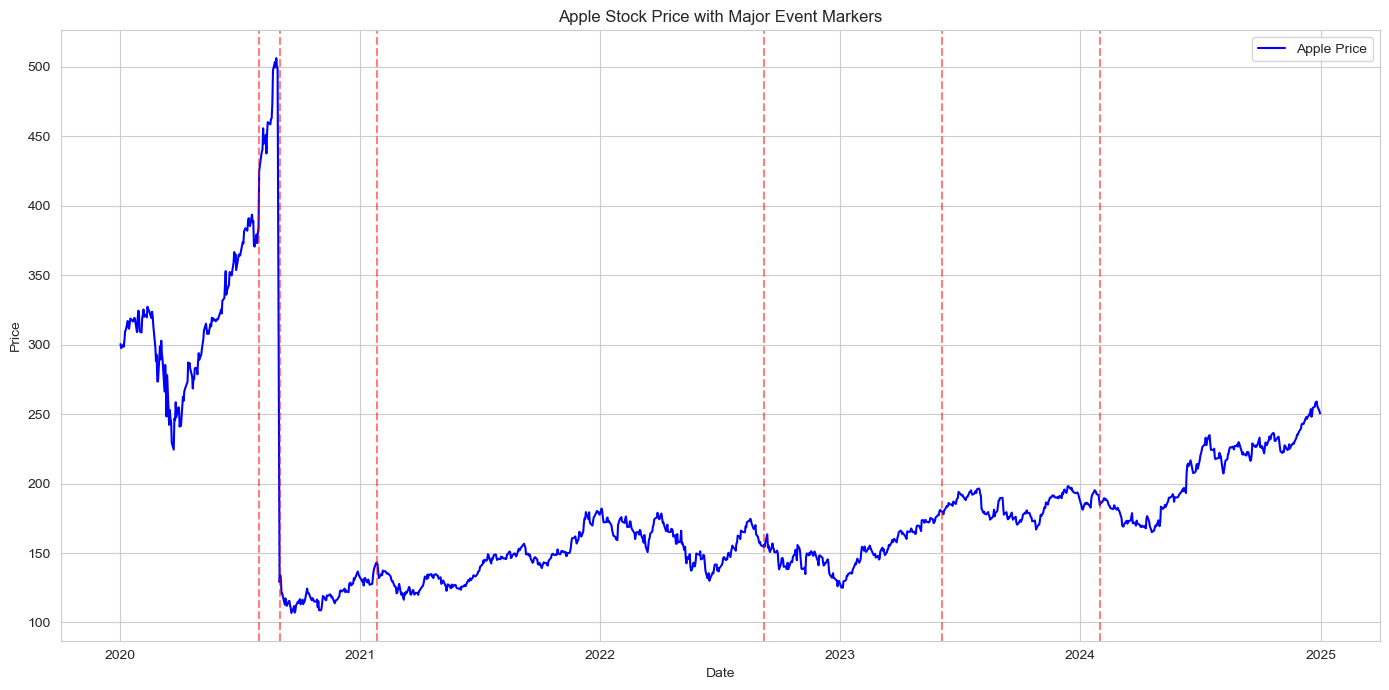

In [14]:
plt.figure(figsize=(14, 7))
plt.plot(aapl["date"], aapl["prc"], label="Price", color="blue")
plt.plot(aapl["date"], aapl["ma_20"], label="20-Day MA", color="red")
plt.plot(aapl["date"], aapl["ma_50"], label="50-Day MA", color="black")

for _, row in events.iterrows():
    plt.axvline(row["Event_Date"], color="gray", linestyle="--", alpha=0.3)

plt.title("Apple Stock Price with Moving Averages and Event Markers")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "price_moving_averages.png", dpi=300)
plt.show()

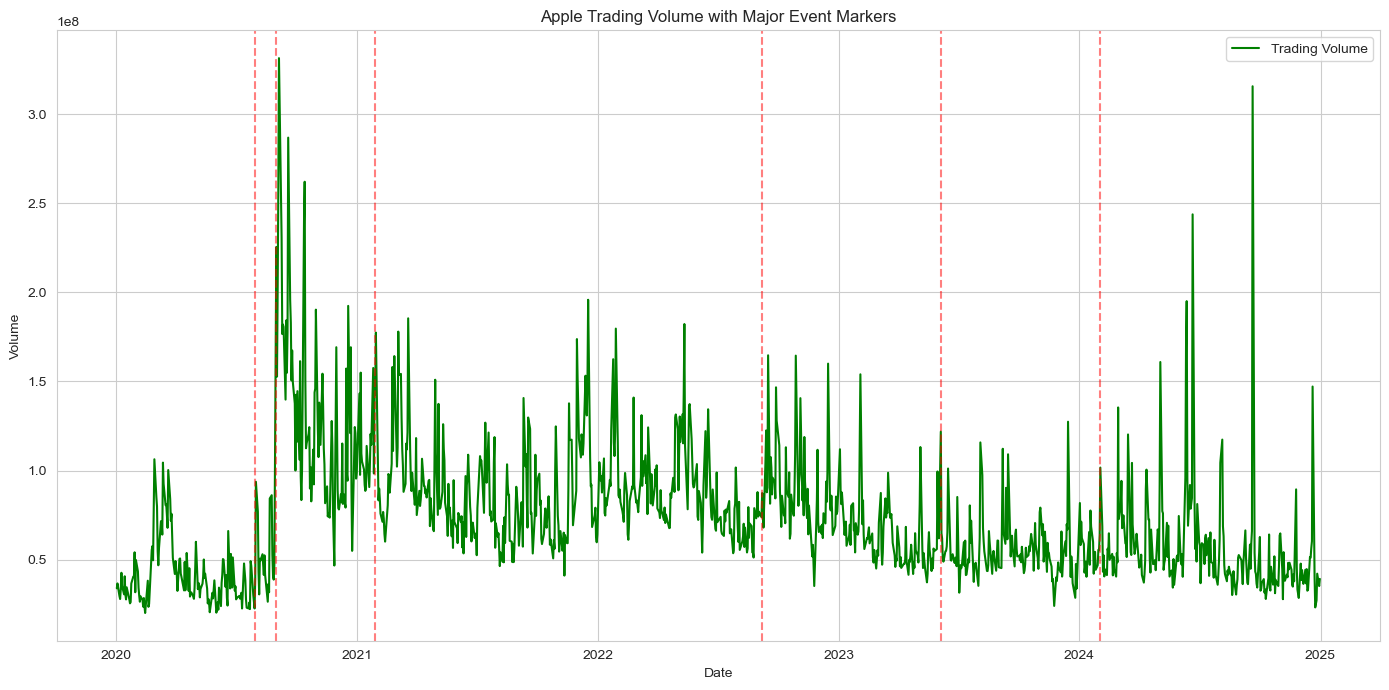

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

axes[0].plot(aapl["date"], aapl["vol"], color="green")
axes[0].set_title("Apple Trading Volume")
axes[0].set_ylabel("Volume")

axes[1].plot(aapl["date"], aapl["volatility_20"], color="orange")
axes[1].set_title("Apple 20-Day Rolling Volatility")
axes[1].set_ylabel("Volatility")
axes[1].set_xlabel("Date")

for ax in axes:
    for _, row in events.iterrows():
        ax.axvline(row["Event_Date"], color="gray", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "volume_volatility.png", dpi=300)
plt.show()

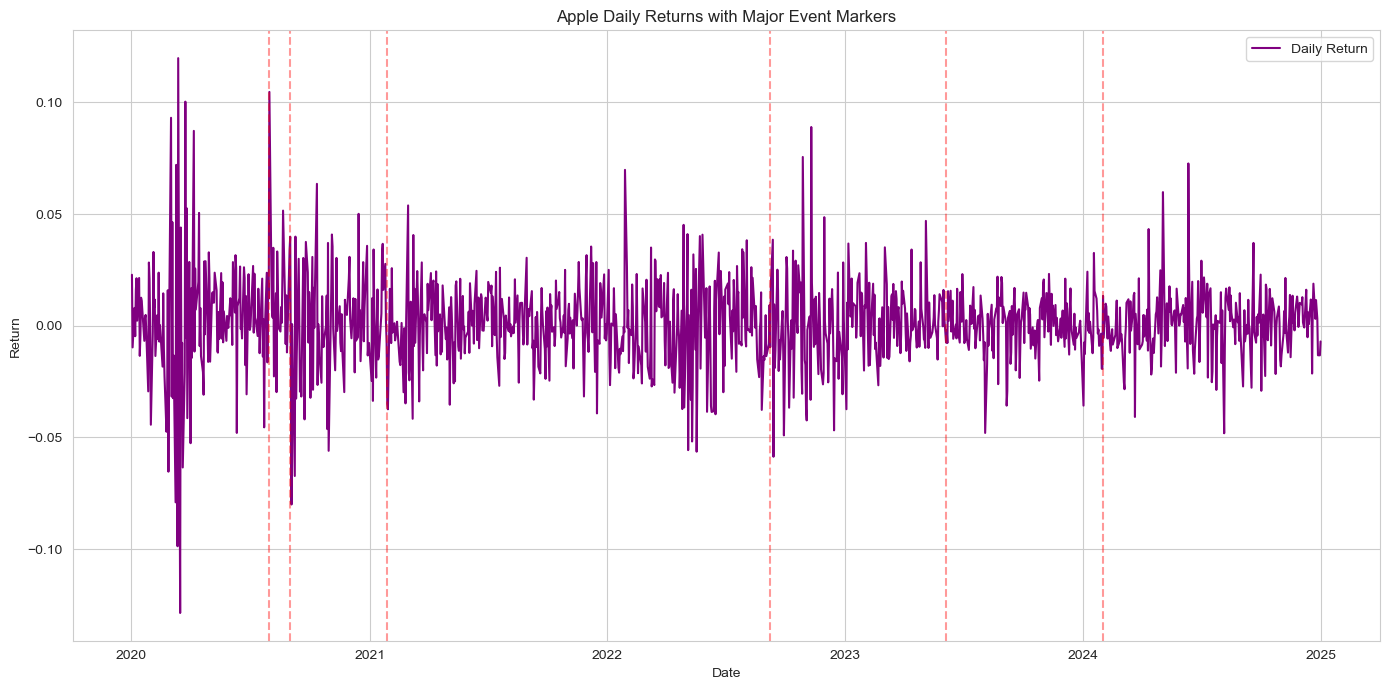

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(aapl["ret"].dropna(), bins=50, kde=True, color="skyblue")
plt.title("Distribution of Apple Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIG_DIR / "return_distribution.png", dpi=300)
plt.show()

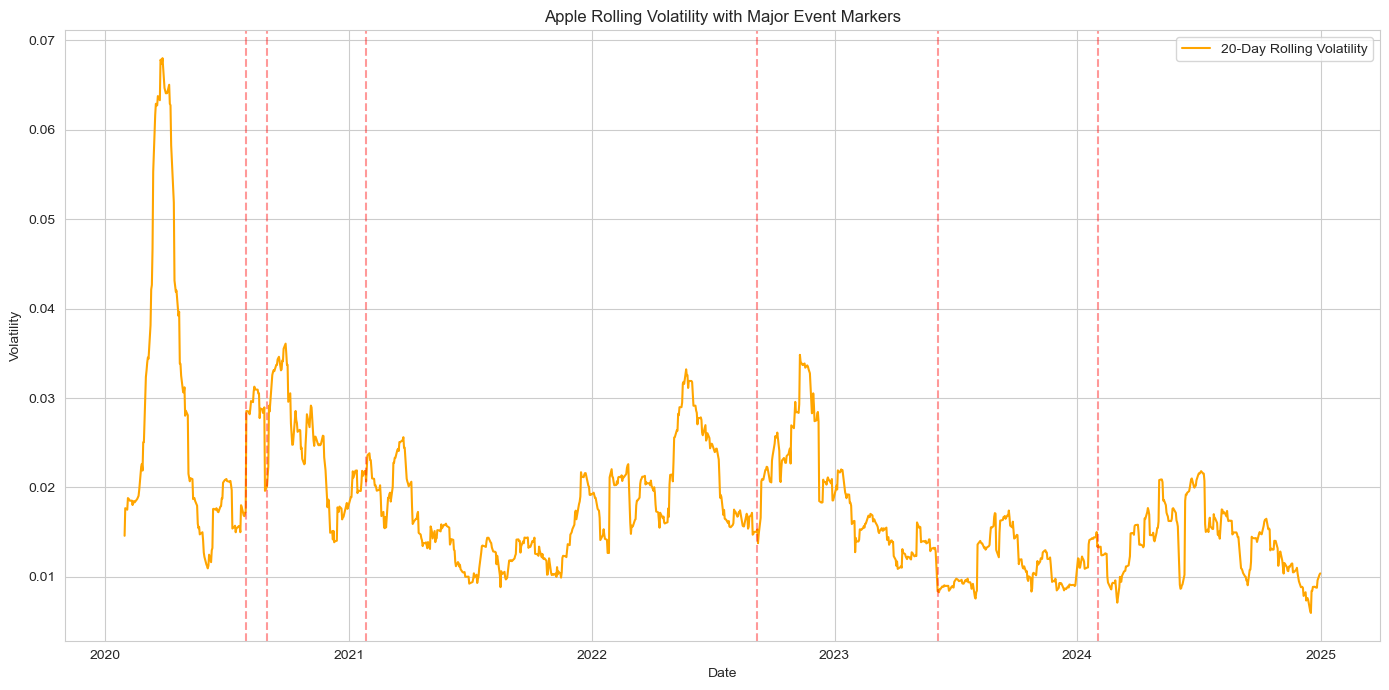

In [17]:
def map_to_trading_day(stock_df, event_date):
    stock_dates = stock_df["date"].sort_values().reset_index(drop=True)
    idx = stock_dates.searchsorted(event_date)

    if idx >= len(stock_dates):
        idx = len(stock_dates) - 1

    mapped_date = stock_dates.iloc[idx]
    return mapped_date

In [18]:
def extract_event_window(stock_df, event_date, window=5):
    mapped_date = map_to_trading_day(stock_df, event_date)
    stock_df = stock_df.sort_values("date").reset_index(drop=True)

    event_idx = stock_df.index[stock_df["date"] == mapped_date][0]
    start_idx = max(0, event_idx - window)
    end_idx = min(len(stock_df) - 1, event_idx + window)

    window_df = stock_df.loc[start_idx:end_idx].copy()
    window_df["Day_Relative"] = range(start_idx - event_idx, end_idx - event_idx + 1)
    window_df["Mapped_Event_Date"] = mapped_date
    window_df["Original_Event_Date"] = event_date

    base_price = stock_df.loc[event_idx, "prc"]
    window_df["Normalized_Price"] = window_df["prc"] / base_price * 100

    return window_df

Event window function created.


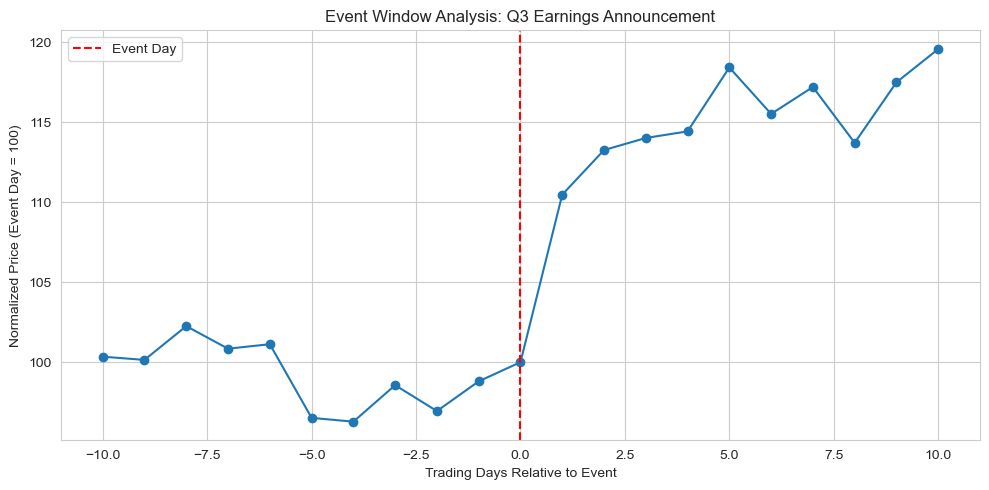

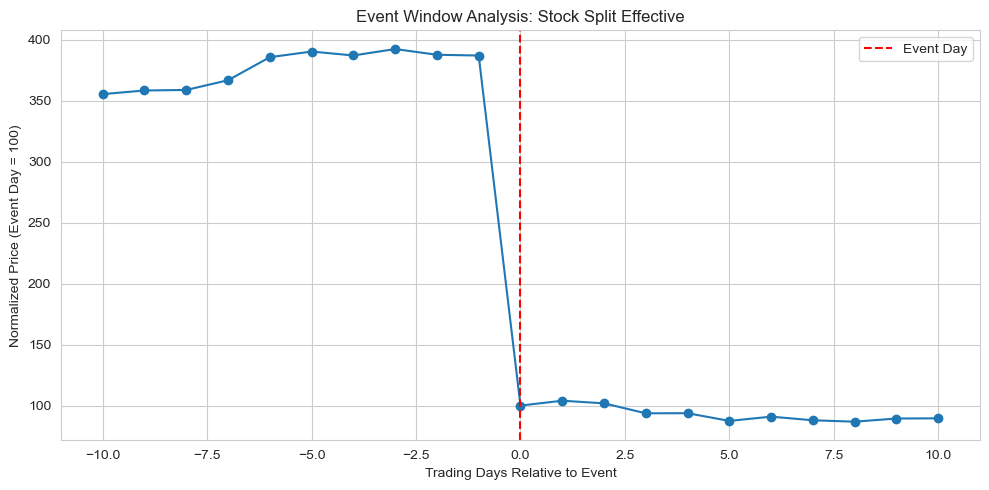

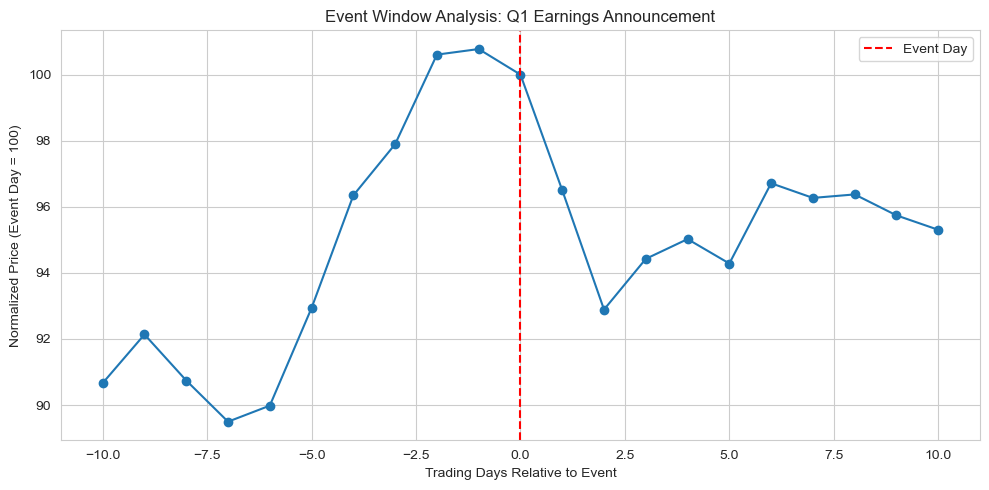

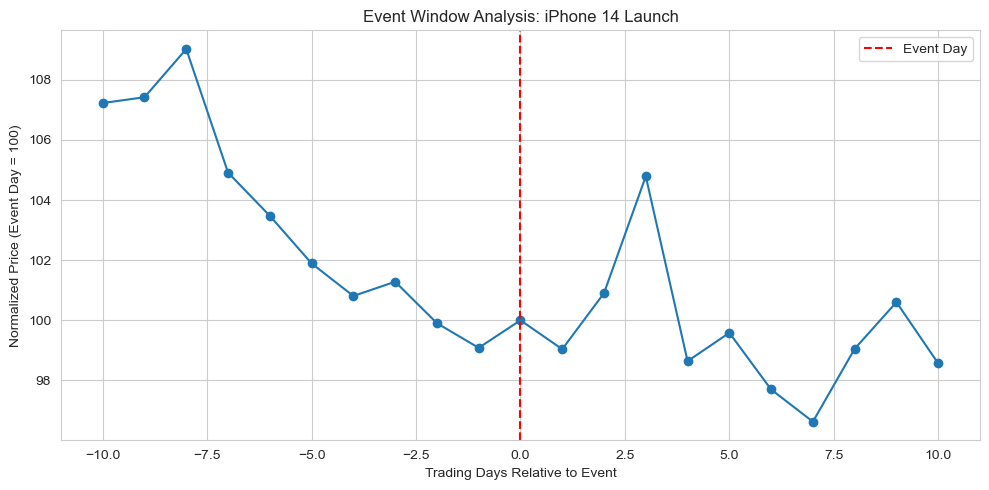

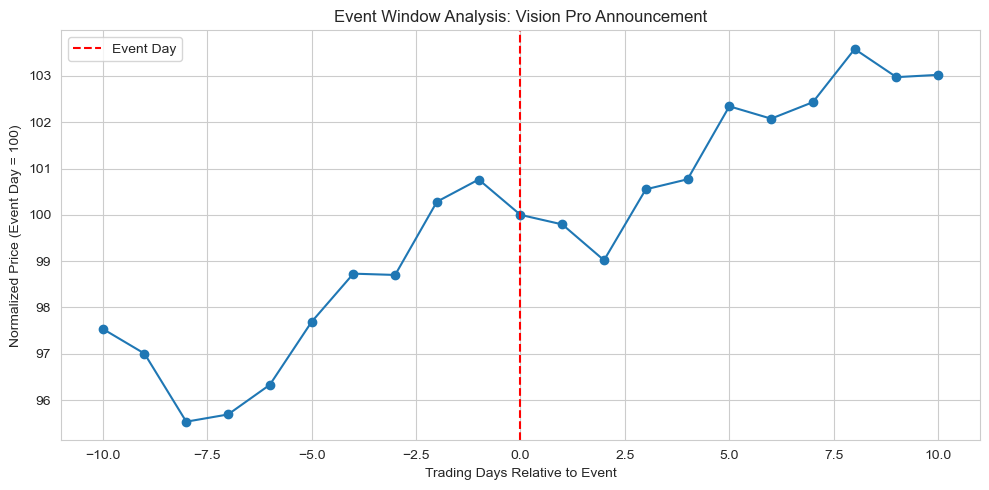

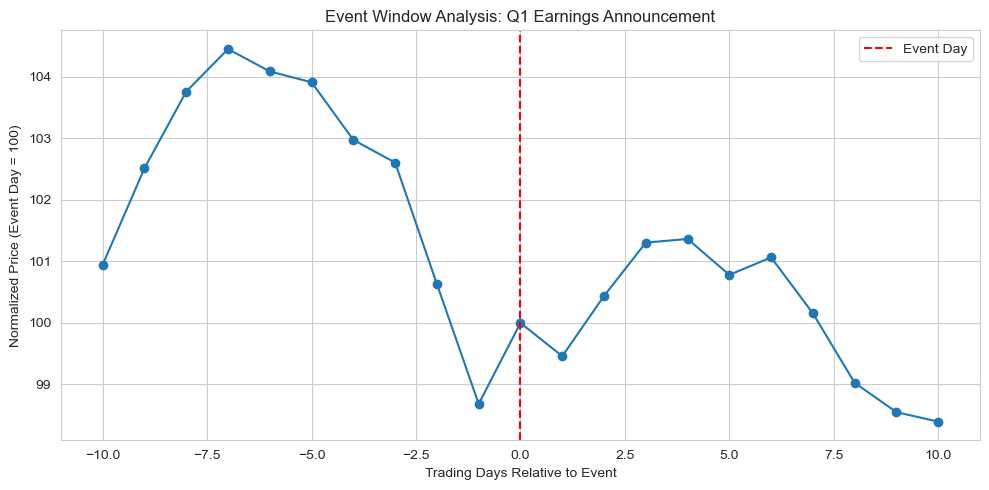

In [19]:
for _, event in events.iterrows():
    window_df = extract_event_window(aapl, event["Event_Date"], window=10)

    plt.figure(figsize=(10, 5))
    plt.plot(window_df["Day_Relative"], window_df["Normalized_Price"], marker="o")
    plt.axvline(0, color="red", linestyle="--", label="Event Day")
    plt.title(f"{event['Event_Name']} ({event['Event_Type']})")
    plt.xlabel("Trading Days Relative to Event")
    plt.ylabel("Normalized Price (Event Day = 100)")
    plt.legend()
    plt.tight_layout()

    filename = f"event_window_{event['Event_Name'].replace(' ', '_').lower()}.png"
    plt.savefig(FIG_DIR / filename, dpi=300)
    plt.show()

In [20]:
event_summary = []

for _, event in events.iterrows():
    window_df = extract_event_window(aapl, event["Event_Date"], window=5)

    pre_df = window_df[window_df["Day_Relative"] < 0]
    post_df = window_df[window_df["Day_Relative"] > 0]
    event_day_df = window_df[window_df["Day_Relative"] == 0]

    event_summary.append({
        "Event_Name": event["Event_Name"],
        "Event_Type": event["Event_Type"],
        "Original_Event_Date": event["Event_Date"],
        "Mapped_Event_Date": window_df["Mapped_Event_Date"].iloc[0],
        "Event_Day_Return": event_day_df["ret"].mean(),
        "Avg_Return_Pre_5D": pre_df["ret"].mean(),
        "Avg_Return_Post_5D": post_df["ret"].mean(),
        "Volatility_Pre_5D": pre_df["ret"].std(),
        "Volatility_Post_5D": post_df["ret"].std(),
        "Avg_Volume_Pre_5D": pre_df["vol"].mean(),
        "Avg_Volume_Post_5D": post_df["vol"].mean(),
        "Price_Change_Post_5D": post_df["Normalized_Price"].iloc[-1] - 100 if len(post_df) > 0 else np.nan
    })

event_summary_df = pd.DataFrame(event_summary)
event_summary_df.to_csv(TABLE_DIR / "event_summary.csv", index=False)

print(event_summary_df)

Event Summary:
  Event_Date                Event_Name        Event_Type  Avg_Return_Pre_5D  \
0 2020-07-30  Q3 Earnings Announcement          Earnings          -0.004311   
1 2020-08-31     Stock Split Effective  Corporate Action           0.000756   
2 2021-01-27  Q1 Earnings Announcement          Earnings           0.022990   
3 2022-09-07          iPhone 14 Launch    Product Launch          -0.008612   
4 2023-06-05   Vision Pro Announcement    Product Launch           0.009056   
5 2024-02-01  Q1 Earnings Announcement          Earnings          -0.010580   

   Avg_Return_Post_5D  Volatility_Pre_5D  Volatility_Post_5D  \
0            0.035016           0.028213            0.041046   
1           -0.025516           0.011597            0.049243   
2           -0.011465           0.014214            0.024190   
3           -0.000279           0.007929            0.036961   
4            0.004690           0.006748            0.010522   
5            0.001580           0.008403       

In [21]:
type_summary = event_summary_df.groupby("Event_Type")[[
    "Event_Day_Return",
    "Avg_Return_Post_5D",
    "Volatility_Post_5D",
    "Avg_Volume_Post_5D",
    "Price_Change_Post_5D"
]].mean().reset_index()

type_summary.to_csv(TABLE_DIR / "event_type_summary.csv", index=False)

print("Average outcomes by event type:")
print(type_summary)

Conclusion:
Using Apple daily stock data downloaded from WRDS, this notebook examined how major Apple-related events
are associated with stock price changes, trading volume, and volatility.
The results suggest that some earnings announcements, product launches, and corporate actions
coincide with noticeable short-term market reactions.


In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=event_summary_df, x="Event_Type", y="Avg_Return_Post_5D", estimator=np.mean, errorbar=None)
plt.title("Average Post-Event 5-Day Return by Event Type")
plt.xlabel("Event Type")
plt.ylabel("Average Post-Event Return")
plt.tight_layout()
plt.savefig(FIG_DIR / "post_event_return_by_type.png", dpi=300)
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=event_summary_df, x="Event_Type", y="Avg_Volume_Post_5D", estimator=np.mean, errorbar=None)
plt.title("Average Post-Event Trading Volume by Event Type")
plt.xlabel("Event Type")
plt.ylabel("Average Volume")
plt.tight_layout()
plt.savefig(FIG_DIR / "post_event_volume_by_type.png", dpi=300)
plt.show()